# Data Preparation

In [52]:
import yfinance as yf
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/aapl_data.csv")
data = data.set_index("Date")
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-05-20,29.129120,29.335169,28.967864,29.115682,145819600
2015-05-21,29.426994,29.480748,29.077607,29.131360,158921600
2015-05-22,29.684561,29.780868,29.429239,29.474035,182384000
2015-05-26,29.030577,29.767429,28.918593,29.698000,282790400
2015-05-27,29.572575,29.621848,29.126883,29.191832,183332800


In [53]:
df = data.copy()

series = np.log(df["Close"])
forcasting_period = 5

series

Date
2015-05-20    3.371738
2015-05-21    3.381912
2015-05-22    3.390627
2015-05-26    3.368350
2015-05-27    3.386847
                ...   
2025-05-13    5.360963
2025-05-14    5.358142
2025-05-15    5.353989
2025-05-16    5.353090
2025-05-19    5.341281
Name: Close, Length: 2515, dtype: float64

## Plot

### Distribution:

/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_1480/3570667372.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF \nmu={mu}, \nsigma={std}', c="blue")


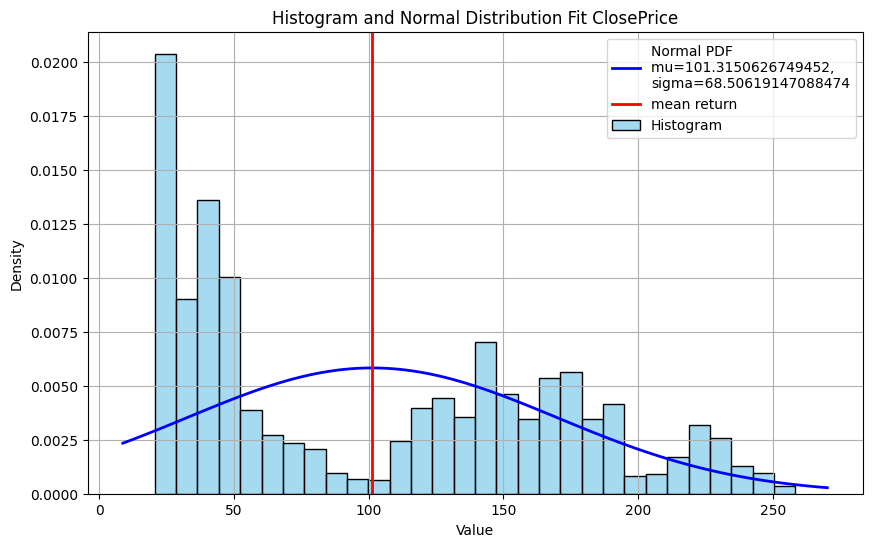

/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_1480/3570667372.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF \nmu={mu}, \nsigma={std}', c="blue")


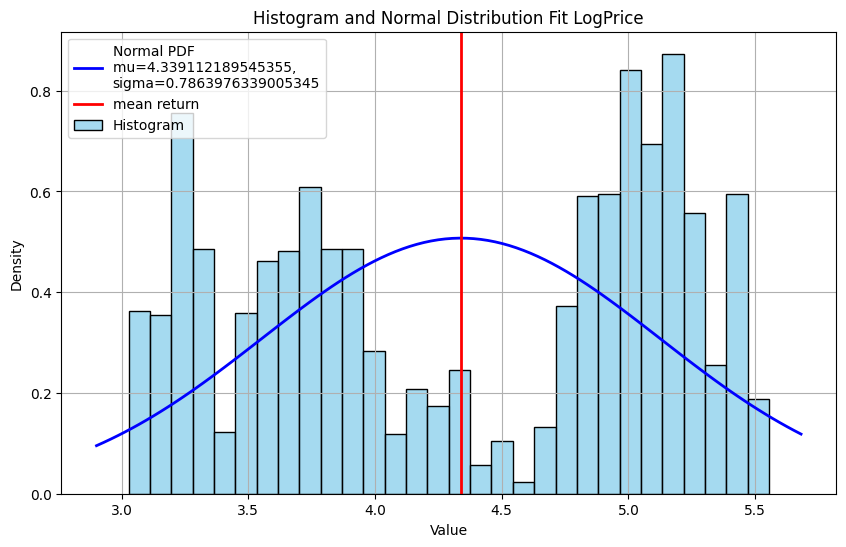

/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_1480/3570667372.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF \nmu={mu}, \nsigma={std}', c="blue")


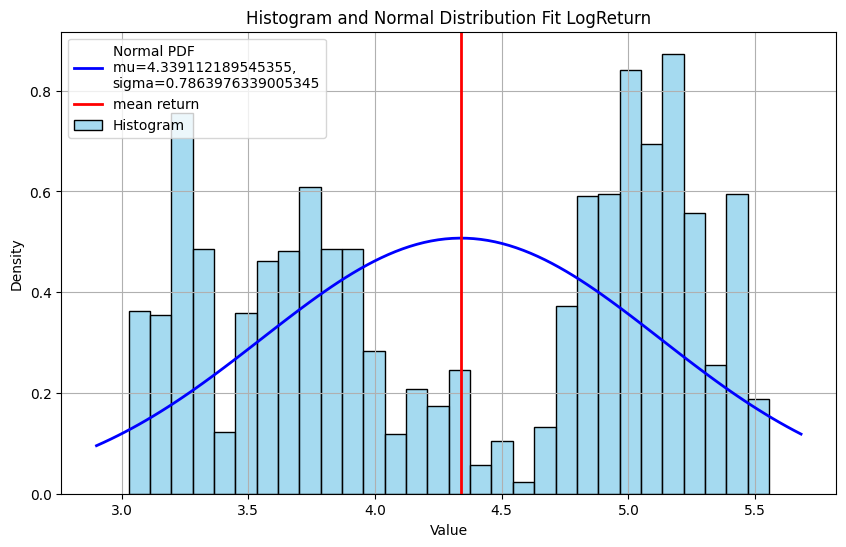

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

def distribution_plot(series, series_name):
    # Plot histogram and theoretical distribution line
    plt.figure(figsize=(10, 6))
    sns.histplot(series, kde=False, stat='density', bins=30, color='skyblue', label='Histogram')

    # Fit a normal distribution and plot the PDF
    mu, std = norm.fit(series)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth=2, label=f'Normal PDF \nmu={mu}, \nsigma={std}', c="blue")
    plt.axvline(x=mu, label="mean return", c="red", linewidth=2)
    plt.title(f'Histogram and Normal Distribution Fit {series_name}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

distribution_plot(series= df["Close"], series_name= "ClosePrice")
distribution_plot(series= np.log(df["Close"]), series_name= "LogPrice")
distribution_plot(series= series, series_name= "LogReturn")

### Boxplot:

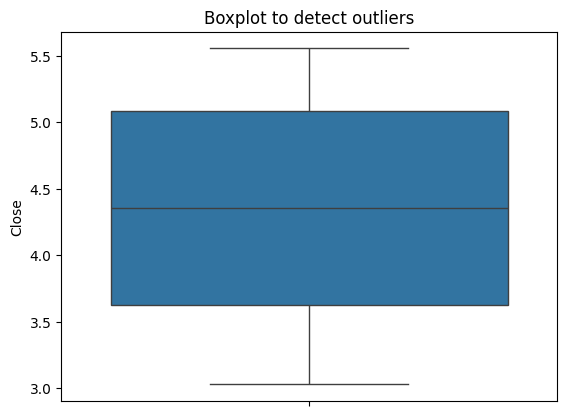

In [55]:
# Boxplot
sns.boxplot(data= series)
plt.title("Boxplot to detect outliers")
plt.show()

In [56]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df))
outliers = (z_scores > 3).any(axis=1)
print(f"Outliers found: {outliers.sum()} rows")

Outliers found: 48 rows


### Skew, Kurtosis

In [57]:
from scipy.stats import skew, kurtosis

for col in df.columns:
    print(f"{col}: skew = {skew(df[col]):.2f}, kurtosis = {kurtosis(df[col]):.2f}")

Close: skew = 0.41, kurtosis = -1.23
High: skew = 0.40, kurtosis = -1.24
Low: skew = 0.41, kurtosis = -1.23
Open: skew = 0.41, kurtosis = -1.23
Volume: skew = 2.08, kurtosis = 7.14


## Series Define

Date
2015-05-20    3.371738
2015-05-21    3.381912
2015-05-22    3.390627
2015-05-26    3.368350
2015-05-27    3.386847
                ...   
2025-05-13    5.360963
2025-05-14    5.358142
2025-05-15    5.353989
2025-05-16    5.353090
2025-05-19    5.341281
Name: Close, Length: 2515, dtype: float64


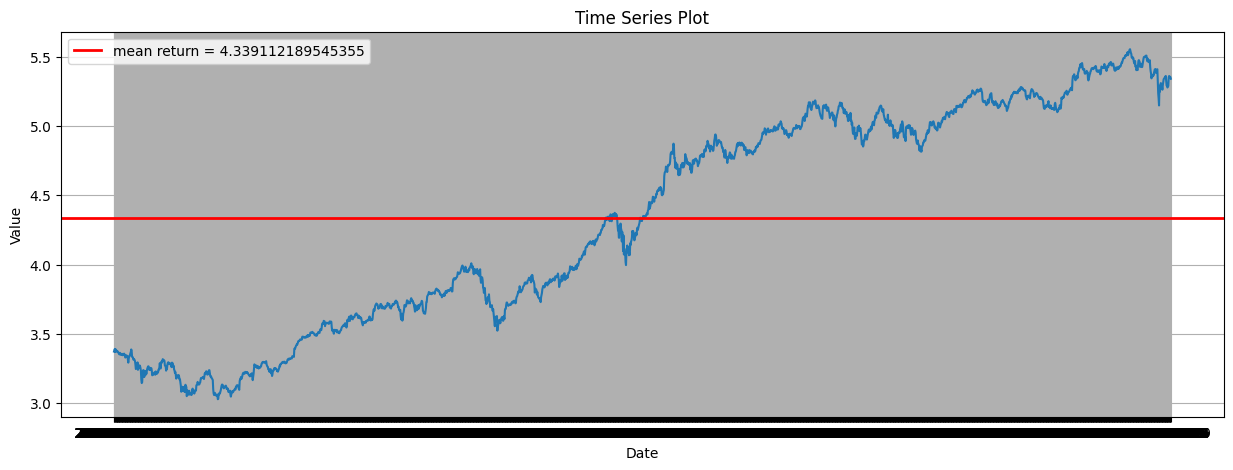

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mu = series.mean()
print(series)
# Visualize the raw time series
plt.figure(figsize=(15, 5))
plt.plot(series)
plt.axhline(mu, c="red", linewidth=2, label=f"mean return = {mu}")
plt.title("Time Series Plot")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

## Stationary Test with ADF and Q-Q

In [59]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# ADF Test
result = adfuller(series)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# First differencing if needed
if result[1] > 0.05:
    diff = series.diff().dropna()
    print("After differencing:")
    result_diff = adfuller(diff)
    print(f"ADF Statistic: {result_diff[0]}")
    print(f"p-value: {result_diff[1]}")

ADF Statistic: -0.5309122836579312
p-value: 0.8858417096094248
After differencing:
ADF Statistic: -15.873020545401953
p-value: 8.936356708288555e-29


=> **The data is stationary** => You can use time series models like ARIMA or GARCH without differencing further.

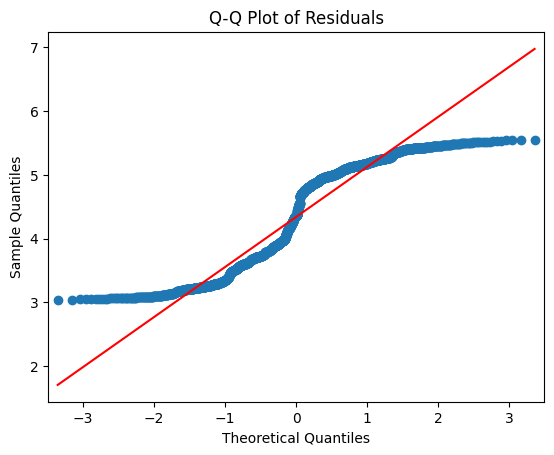

In [60]:
import statsmodels.api as sm

sm.qqplot(series.dropna(), line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

## ACF and PACF

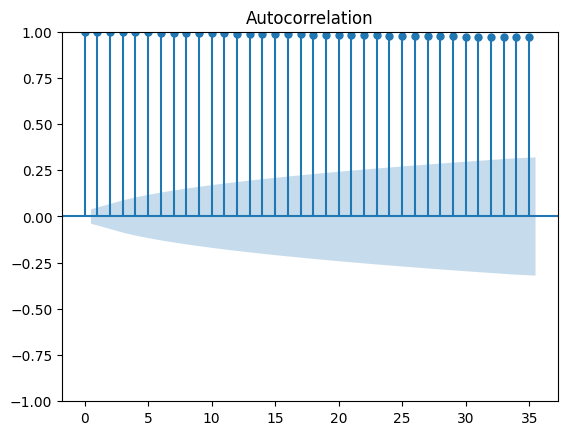

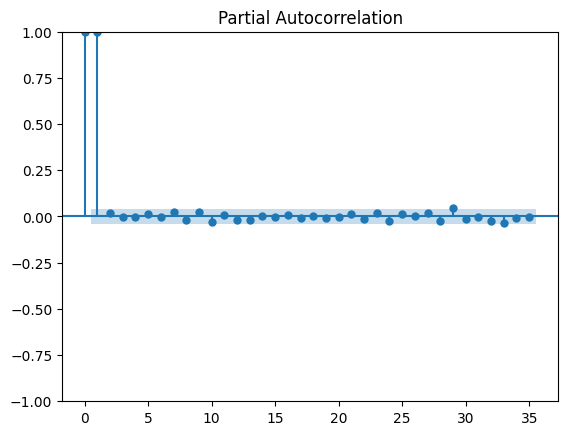

In [61]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(series); plot_pacf(series);

# ARIMA

## Model Building

### Optimal Parameters:

In [62]:
!pip install pmdarima


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [63]:
from pmdarima.arima import auto_arima

train, test = series[:-forcasting_period].copy(), series[-forcasting_period:].copy()
model_arima = auto_arima(
    train, start_p=0, start_q=0,
    max_p=5, max_q=5, m=12, d=1,
    start_P=0, seasonal= False,
    trace=True,
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

Performing stepwise search to minimize aic


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-12896.030, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-12903.431, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-12903.212, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-12893.475, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-12901.779, Time=0.21 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-12902.035, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-12899.729, Time=0.77 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-12900.312, Time=0.04 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 1.654 seconds


### Model Define:

In [64]:
print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2510
Model:               SARIMAX(1, 1, 0)   Log Likelihood                6454.715
Date:                Fri, 23 May 2025   AIC                         -12903.431
Time:                        20:24:10   BIC                         -12885.948
Sample:                             0   HQIC                        -12897.085
                               - 2510                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0008      0.000      2.237      0.025       0.000       0.002
ar.L1         -0.0613      0.012     -5.086      0.000      -0.085      -0.038
sigma2         0.0003    5.1e-06     66.936      0.0

### Residual Diagnostics

In [65]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = pd.Series(model_arima.resid())
acorr_ljungbox(residuals, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,0.582753,0.999986


Null Hypothesis (H_0): The residuals are independently distributed (no autocorrelation). <br>
Alternative Hypothesis (H_1): **The residuals are autocorrelated**.

## Result

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Final model
forecast = model_arima.predict(len(test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Convert to Price:

In [67]:
def log_return_to_price(last_price, log_returns):
    prices = [last_price]
    for r in log_returns:
        next_price = prices[-1] * np.exp(r)
        prices.append(next_price)
    return prices[1:]  # skip the initial last_price

def log_price_to_price(log_price):
    return np.exp(log_price)

prediction = np.array( log_price_to_price(forecast) )
valid = df["Close"][-forcasting_period:]

### Validation:


Next 5-step forecast:
 [210.17506685 210.38758871 210.54957433 210.71479737 210.87995913]


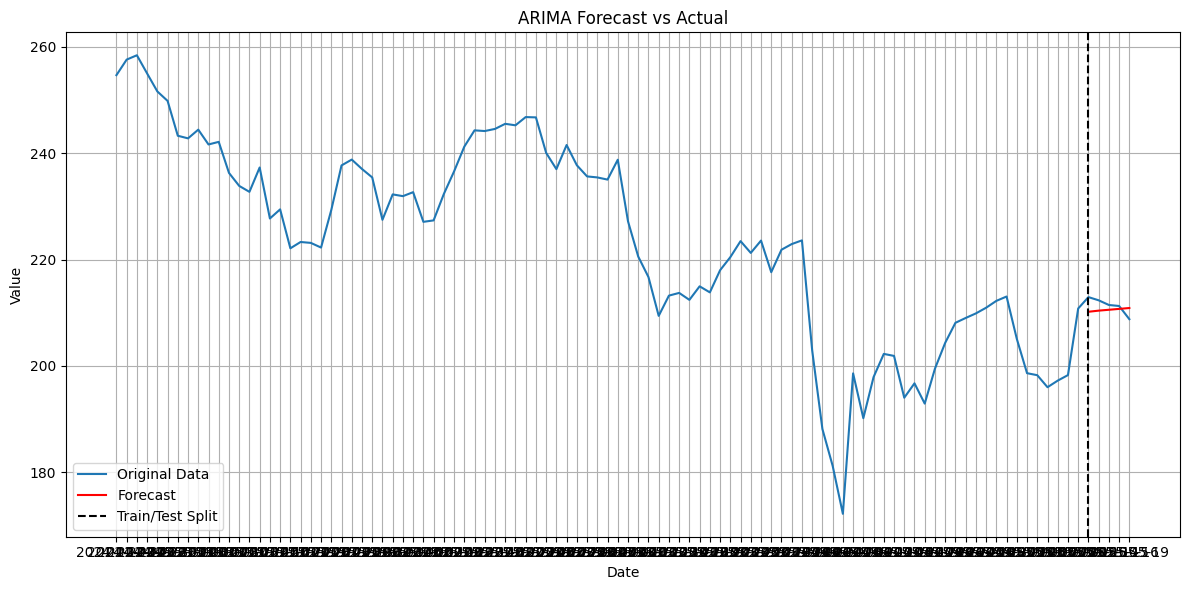

In [68]:
print(f"\nNext {forcasting_period}-step forecast:\n", prediction)

# Plot full series and forecast
plt.figure(figsize=(12, 6))
plt.plot(df["Close"][-100:], label="Original Data")
plt.plot(valid.index, prediction, label="Forecast", color="red")
plt.axvline(x= valid.index[0], color="black", linestyle="--", label="Train/Test Split")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [69]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse = mean_squared_error(valid, prediction, squared=False)
mae = mean_absolute_error(valid, prediction)
mape = mean_absolute_percentage_error(valid, prediction)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")

RMSE: 1.8374
MAE: 1.6486
MAPE: 0.0078


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Residuals check:

In [70]:
import pandas as pd
import numpy as np

# Assuming forecast and actual (test) are pandas Series with aligned indices
actual = valid.to_numpy()

residuals = actual - prediction
abs_errors = np.abs(residuals)

# Combine into a DataFrame for inspection
errors_df = pd.DataFrame({
    'Actual': actual,
    'Forecast': prediction,
    'Residual': residuals,
    'Absolute Error': abs_errors
})

# Sort by absolute error (largest error first)
sorted_errors = errors_df.sort_values(by='Absolute Error', ascending=False)

# Show top N worst predictions
print(sorted_errors.head(10))

       Actual    Forecast  Residual  Absolute Error
0  212.929993  210.175067  2.754926        2.754926
4  208.779999  210.879959 -2.099960        2.099960
1  212.330002  210.387589  1.942413        1.942413
2  211.449997  210.549574  0.900423        0.900423
3  211.259995  210.714797  0.545197        0.545197


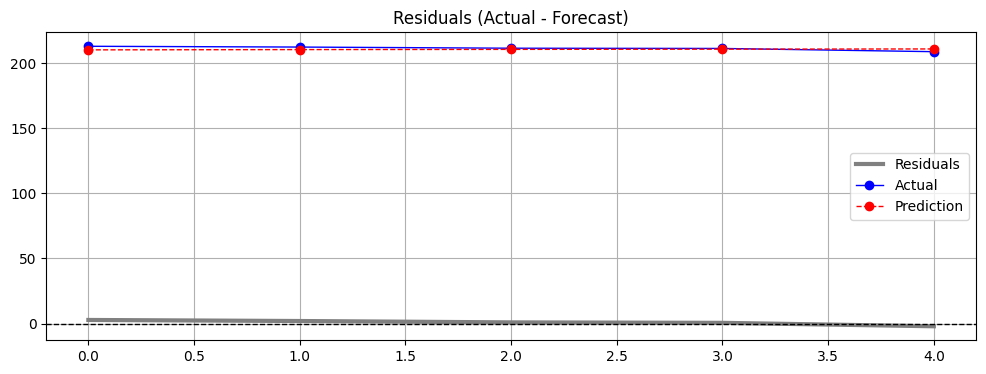

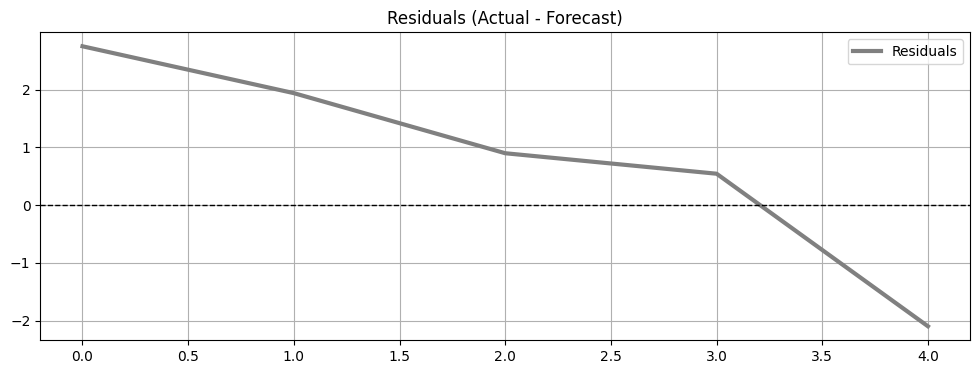

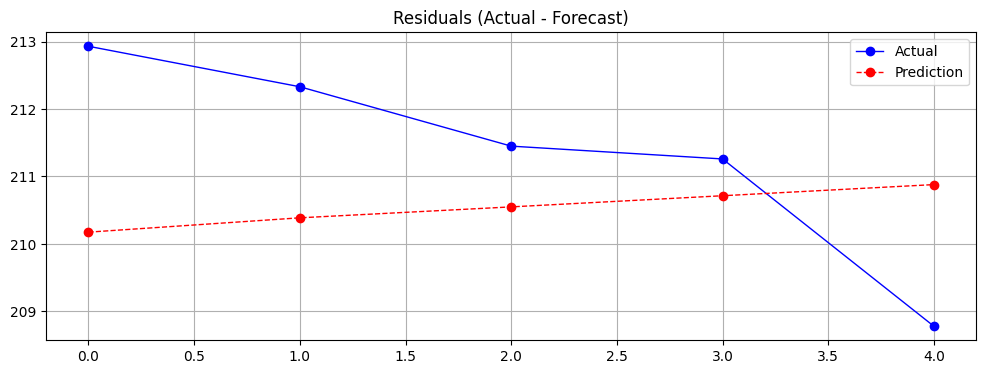

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(errors_df['Residual'], label='Residuals', c="gray", linewidth=3)
plt.plot(actual, marker="o", label= "Actual", c="blue", linewidth=1)
plt.plot(prediction, marker="o", label= "Prediction", c="red", linewidth=1, linestyle="--")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals (Actual - Forecast)')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(errors_df['Residual'], label='Residuals', c="gray", linewidth=3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals (Actual - Forecast)')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(actual, marker="o", label= "Actual", c="blue", linewidth=1)
plt.plot(prediction, marker="o", label= "Prediction", c="red", linewidth=1, linestyle="--")
plt.title('Residuals (Actual - Forecast)')
plt.grid()
plt.legend()
plt.show()

In [72]:
from arch import arch_model

garch = arch_model(model_arima.resid(), vol='GARCH', p=1, q=1)
garch_result = garch.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 139817664.30844846
Iteration:      2,   Func. Count:     21,   Neg. LLF: 1.238733236193417e+22
Iteration:      3,   Func. Count:     36,   Neg. LLF: 772.760355494513
Iteration:      4,   Func. Count:     41,   Neg. LLF: 340.4221042316251
Iteration:      5,   Func. Count:     48,   Neg. LLF: 7111.847710011625
Iteration:      6,   Func. Count:     57,   Neg. LLF: 1552543.5956463995
Iteration:      7,   Func. Count:     72,   Neg. LLF: 17700054324686.605
Iteration:      8,   Func. Count:     87,   Neg. LLF: 7444.208466926958
Iteration:      9,   Func. Count:     93,   Neg. LLF: 5361.651484695371
Iteration:     10,   Func. Count:     98,   Neg. LLF: 8746.909089913846
Iteration:     11,   Func. Count:    105,   Neg. LLF: 3142.62925049251
Iteration:     12,   Func. Count:    112,   Neg. LLF: 2147153.113819821
Iteration:     13,   Func. Count:    118,   Neg. LLF: 8743.027128366572
Iteration:     14,   Func. Count:    126,   Neg. LLF: 28970

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.004866. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


[5.34794084 5.34895149 5.34972113 5.35050555 5.35128906]
[0.00380933 0.00385184 0.00385965 0.00386108 0.00386135]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


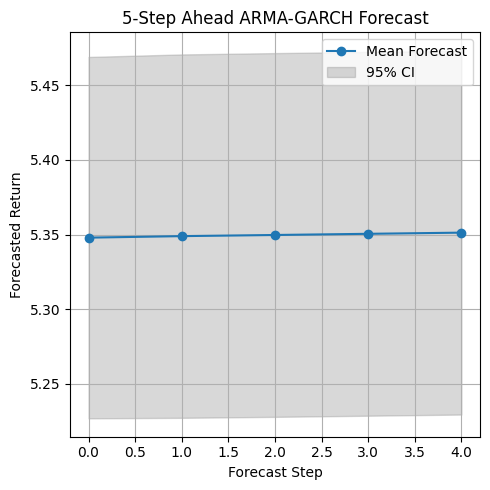

In [73]:
garch_forecast = garch_result.forecast(horizon=forcasting_period)
mean_forecast = model_arima.predict(n_periods=forcasting_period).to_numpy()

print(mean_forecast)

variance_forecast = garch_forecast.variance.values[-1, :]  # last row
print(variance_forecast)

conf_int_upper = mean_forecast + 1.96 * np.sqrt(variance_forecast)
conf_int_lower = mean_forecast - 1.96 * np.sqrt(variance_forecast)

# STEP 5: Plot the forecasts with confidence intervals
plt.figure(figsize=(forcasting_period, 5))
plt.plot(mean_forecast, marker='o', label='Mean Forecast')
plt.fill_between(range(forcasting_period), conf_int_lower, conf_int_upper, color='gray', alpha=0.3, label='95% CI')
plt.title("5-Step Ahead ARMA-GARCH Forecast")
plt.xlabel("Forecast Step")
plt.ylabel("Forecasted Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# SARIMA

## Model Building

### Optimal Parameters:

In [74]:
!pip install pmdarima


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [75]:
from pmdarima.arima import auto_arima

train, test = series[:-forcasting_period].copy(), series[-forcasting_period:].copy()
model_sarima = auto_arima(train, start_p=0, start_q=0,
                           max_p=5, max_q=5, m=12,
                           start_P=0, seasonal=True,
                           d=1, D=1, trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=2.59 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-11128.220, Time=0.30 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-11791.453, Time=1.15 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=5.70 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-11134.441, Time=0.16 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-12117.115, Time=2.47 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=26.32 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=9.28 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-12112.869, Time=1.98 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-12115.785, Time=3.24 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=-12116.458, Time=9.52 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=-12116.930, Time=2.39 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=-12113.905, Time=5.07 sec
 ARIMA(1,1,0)(2,1,0)[12] intercept   : AIC=-12115.119, Time=8.51 sec

Best model:  ARIM

### Model Define:

In [76]:
print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 2510
Model:             SARIMAX(1, 1, 0)x(2, 1, 0, 12)   Log Likelihood                6062.557
Date:                            Fri, 23 May 2025   AIC                         -12117.115
Time:                                    20:25:31   BIC                         -12093.823
Sample:                                         0   HQIC                        -12108.658
                                           - 2510                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0574      0.014     -4.228      0.000      -0.084      -0.031
ar.S.L12      -0.6556      0.015   

### Residual Diagnostics

In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = pd.Series(model_sarima.resid())
acorr_ljungbox(residuals, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,1.118857,0.999713


Null Hypothesis (H_0): The residuals are independently distributed (no autocorrelation). <br>
Alternative Hypothesis (H_1): **The residuals are autocorrelated**.

## Result

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Final model
forecast = model_sarima.predict(len(test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Convert to Price:

In [79]:
#prediction = np.array( log_return_to_price(df["Close"][-forcasting_period-1], forecast) )
prediction = np.array( log_price_to_price(forecast) )
valid = df["Close"][-forcasting_period:]

### Validation:


Next 5-step forecast:
 [208.62585956 218.75184609 217.44549465 219.65452062 222.19235266]


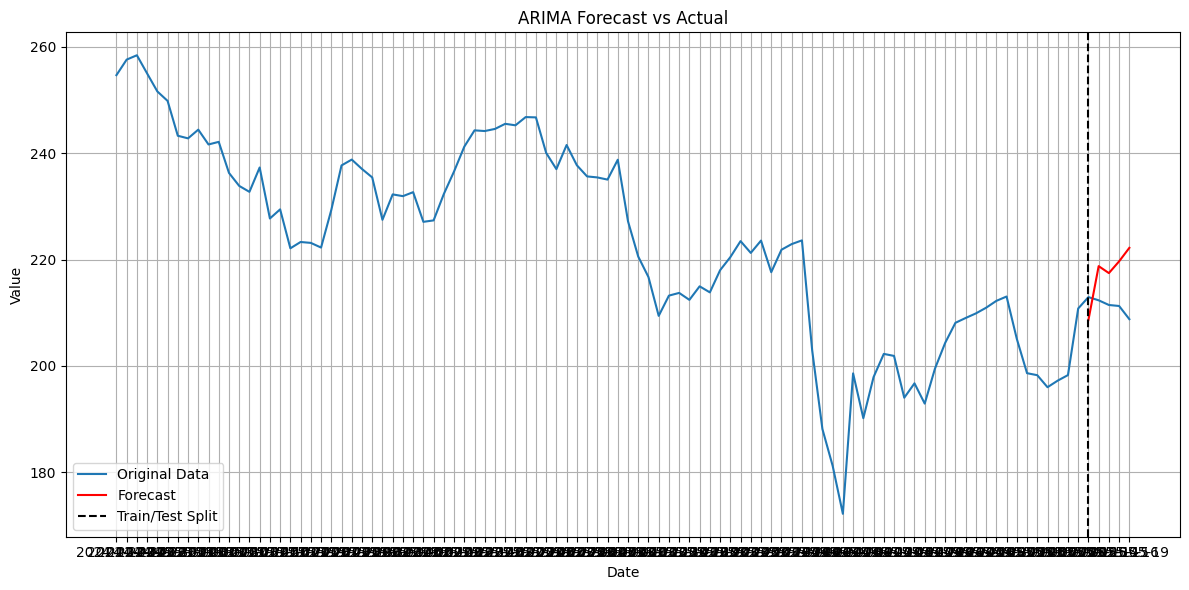

In [80]:
print(f"\nNext {forcasting_period}-step forecast:\n", prediction)

# Plot full series and forecast
plt.figure(figsize=(12, 6))
plt.plot(df["Close"][-100:], label="Original Data")
plt.plot(valid.index, prediction, label="Forecast", color="red")
plt.axvline(x= valid.index[0], color="black", linestyle="--", label="Train/Test Split")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse = mean_squared_error(valid, prediction, squared=False)
mae = mean_absolute_error(valid, prediction)
mape = mean_absolute_percentage_error(valid, prediction)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")

RMSE: 8.3195
MAE: 7.7057
MAPE: 0.0366


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Residuals check:

In [82]:
import pandas as pd
import numpy as np

# Assuming forecast and actual (test) are pandas Series with aligned indices
actual = valid.to_numpy()

residuals = actual - prediction
abs_errors = np.abs(residuals)

# Combine into a DataFrame for inspection
errors_df = pd.DataFrame({
    'Actual': actual,
    'Forecast': prediction,
    'Residual': residuals,
    'Absolute Error': abs_errors
})

# Sort by absolute error (largest error first)
sorted_errors = errors_df.sort_values(by='Absolute Error', ascending=False)

# Show top N worst predictions
print(sorted_errors.head(10))

       Actual    Forecast   Residual  Absolute Error
4  208.779999  222.192353 -13.412354       13.412354
3  211.259995  219.654521  -8.394526        8.394526
1  212.330002  218.751846  -6.421844        6.421844
2  211.449997  217.445495  -5.995498        5.995498
0  212.929993  208.625860   4.304133        4.304133


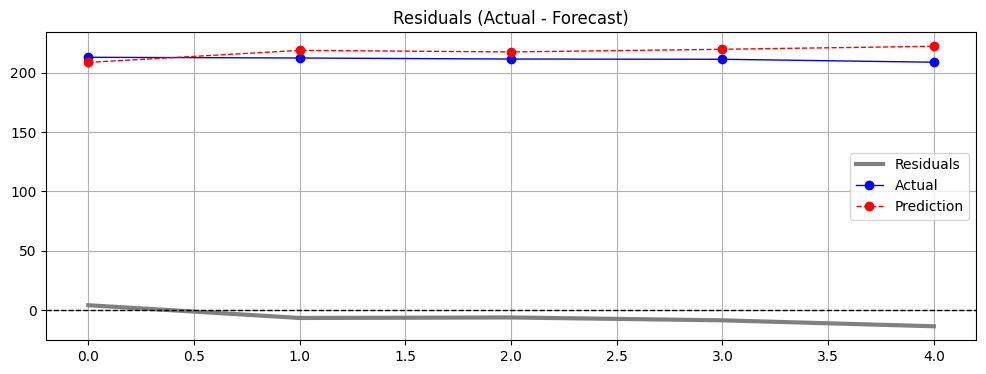

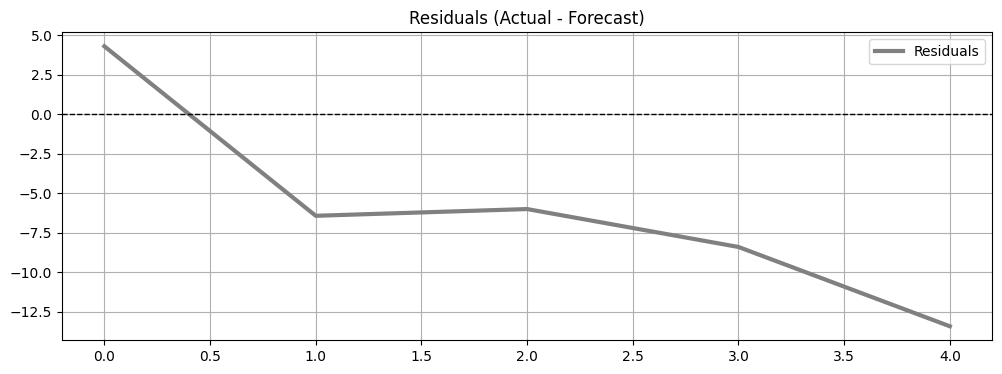

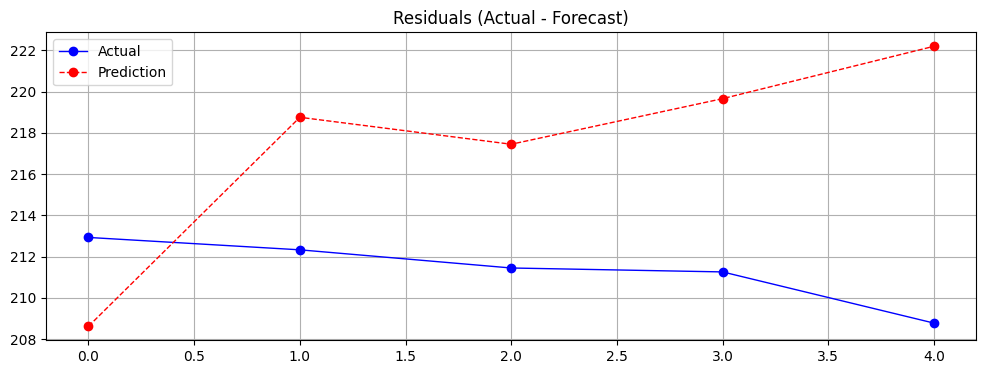

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(errors_df['Residual'], label='Residuals', c="gray", linewidth=3)
plt.plot(actual, marker="o", label= "Actual", c="blue", linewidth=1)
plt.plot(prediction, marker="o", label= "Prediction", c="red", linewidth=1, linestyle="--")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals (Actual - Forecast)')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(errors_df['Residual'], label='Residuals', c="gray", linewidth=3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals (Actual - Forecast)')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(actual, marker="o", label= "Actual", c="blue", linewidth=1)
plt.plot(prediction, marker="o", label= "Prediction", c="red", linewidth=1, linestyle="--")
plt.title('Residuals (Actual - Forecast)')
plt.grid()
plt.legend()
plt.show()